# S&DS 265 · Lecture 03 demo
## Linear regression: the closed form, and why we abandon it

This notebook is the companion to Lecture 03. It uses the **Advertising** data set from
*An Introduction to Statistical Learning* (James, Witten, Hastie, Tibshirani, Taylor, 2023),
the same 200 markets we worked through on the slides.

You will:

1. compute the least-squares line by hand and check it against a library;
2. see the newspaper coefficient die once radio is in the model;
3. write gradient descent in six lines and watch the learning rate control everything;
4. **time** the closed form against gradient descent and see the $O(np^2)$ vs $O(np)$ gap;
5. see why the optimizer does not need to be run to high precision.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.figsize': (8, 3.4), 'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False})
BLUE, RED, GREEN, MUTED = '#00356B', '#985B63', '#5B7864', '#66727E'
rng = np.random.default_rng(265)

### The data

`Advertising.csv` sits beside this notebook, so the cell below opens it directly.

In [2]:
ad = pd.read_csv('Advertising.csv', index_col=0)
print(ad.shape)
ad.head()

(200, 4)


,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [3]:
ad.describe().round(2)

,TV,radio,newspaper,sales
count,200.00,200.00,200.00,200.00
mean,147.04,23.26,30.55,14.02
std,85.85,14.85,21.78,5.22
min,0.70,0.00,0.30,1.60
25%,74.38,9.98,12.75,10.38
50%,149.75,22.90,25.75,12.90
75%,218.82,36.52,45.10,17.40
max,296.40,49.60,114.00,27.00


Note the spread of each column. `TV` ranges over roughly 0–300 while `radio` stops near 50.
That difference looks harmless now. It is the reason gradient descent zigzags in part 3.

## 1. Least squares in one variable, by hand

On the slides we derived

$$\widehat\beta_1=\frac{\sum_i (x_i-\bar x)(y_i-\bar y)}{\sum_i (x_i-\bar x)^2}=\frac{S_{xy}}{S_{xx}},
\qquad \widehat\beta_0=\bar y-\widehat\beta_1\bar x.$$

Type it out and compare with the numbers from class.

In [4]:
x = ad['TV'].to_numpy()
y = ad['sales'].to_numpy()

xbar, ybar = x.mean(), y.mean()
S_xy = ((x - xbar) * (y - ybar)).sum()
S_xx = ((x - xbar) ** 2).sum()

beta1 = S_xy / S_xx
beta0 = ybar - beta1 * xbar

print(f'xbar = {xbar:.3f}   ybar = {ybar:.3f}')
print(f'S_xy = {S_xy:,.1f}   S_xx = {S_xx:,.1f}')
print(f'beta0 = {beta0:.4f}   beta1 = {beta1:.5f}')

xbar = 147.042   ybar = 14.023
S_xy = 69,727.6   S_xx = 1,466,819.0
beta0 = 7.0326   beta1 = 0.04754


Now the same thing through the matrix route, `np.linalg.lstsq`, which is what you should
actually use in practice. It should agree to many digits.

In [5]:
X = np.c_[np.ones_like(x), x]
beta_lstsq, *_ = np.linalg.lstsq(X, y, rcond=None)
print('by hand :', np.array([beta0, beta1]))
print('lstsq   :', beta_lstsq)
print('max abs difference:', np.abs(beta_lstsq - [beta0, beta1]).max())

by hand : [7.03259355 0.04753664]
lstsq   : [7.03259355 0.04753664]
max abs difference: 1.7763568394002505e-15


In [6]:
resid = y - X @ beta_lstsq
RSS = resid @ resid
TSS = ((y - ybar) ** 2).sum()
n, p = X.shape
RSE = np.sqrt(RSS / (n - p))
print(f'RSS = {RSS:.1f}   TSS = {TSS:.1f}')
print(f'R^2 = {1 - RSS/TSS:.4f}   RSE = {RSE:.3f}')

RSS = 2102.5   TSS = 5417.1
R^2 = 0.6119   RSE = 3.259


**Check against the slide.** You should get $\widehat\beta_0=7.033$, $\widehat\beta_1=0.0475$,
$R^2=0.612$, RSE $=3.259$ — and these are exactly ISLP's Table 3.1 and 3.2.

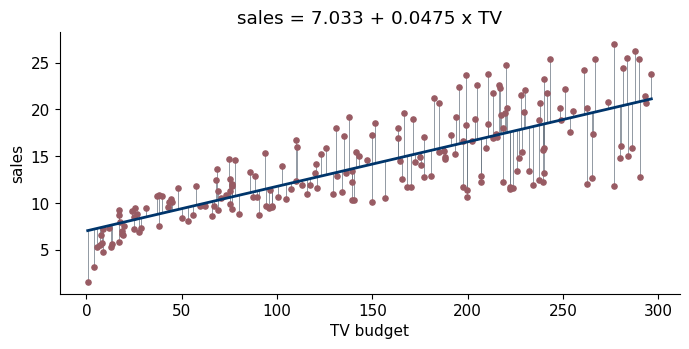

In [7]:
grid = np.linspace(x.min(), x.max(), 2)
fig, ax = plt.subplots()
fit = X @ beta_lstsq
for xi, yi, fi in zip(x, y, fit):
    ax.plot([xi, xi], [fi, yi], color=MUTED, lw=0.5, zorder=1)
ax.scatter(x, y, s=14, color=RED, zorder=3)
ax.plot(grid, beta_lstsq[0] + beta_lstsq[1] * grid, color=BLUE, lw=2, zorder=4)
ax.set(xlabel='TV budget', ylabel='sales',
       title=f'sales = {beta_lstsq[0]:.3f} + {beta_lstsq[1]:.4f} x TV')
plt.show()

## 2. All three channels, and the disappearing newspaper effect

Fit each channel alone, then all three together.

In [8]:
def ols(X, y):
    """Coefficients, standard errors, residuals, and sigma^2."""
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    r = y - X @ beta
    n, p = X.shape
    sigma2 = r @ r / (n - p)
    se = np.sqrt(np.diag(sigma2 * np.linalg.inv(X.T @ X)))
    return beta, se, r, sigma2


for name in ['TV', 'radio', 'newspaper']:
    Xi = np.c_[np.ones(len(ad)), ad[name]]
    b, se, _, _ = ols(Xi, y)
    print(f'{name:10s} slope {b[1]: .4f}   se {se[1]:.4f}   t {b[1]/se[1]: .2f}')

TV         slope  0.0475   se 0.0027   t  17.67
radio      slope  0.2025   se 0.0204   t  9.92
newspaper  slope  0.0547   se 0.0166   t  3.30


In [9]:
Xall = np.c_[np.ones(len(ad)), ad[['TV', 'radio', 'newspaper']].to_numpy()]
b, se, r, s2 = ols(Xall, y)
table = pd.DataFrame({'coefficient': b, 'std. error': se, 't': b / se},
                     index=['intercept', 'TV', 'radio', 'newspaper'])
print(f'RSE = {np.sqrt(s2):.3f}    R^2 = {1 - r @ r / TSS:.4f}')
table.round(4)

RSE = 1.686    R^2 = 0.8972


,coefficient,std. error,t
intercept,2.9389,0.3119,9.4223
TV,0.0458,0.0014,32.8086
radio,0.1885,0.0086,21.8935
newspaper,-0.0010,0.0059,-0.1767


Newspaper went from a clearly positive slope on its own to indistinguishable from zero.
The correlation matrix explains it.

In [10]:
ad.corr().round(4)

,TV,radio,newspaper,sales
TV,1.0000,0.0548,0.0566,0.7822
radio,0.0548,1.0000,0.3541,0.5762
newspaper,0.0566,0.3541,1.0000,0.2283
sales,0.7822,0.5762,0.2283,1.0000


`radio` and `newspaper` correlate at 0.354. Markets that buy radio also buy newspaper, so in a
simple regression newspaper gets credit for radio's effect. Once radio is in the model and held
fixed, there is nothing left for newspaper to explain.

## 3. Gradient descent from scratch

The whole algorithm, for $L(\beta)=\tfrac1n\|y-X\beta\|_2^2$ with
$\nabla L(\beta)=\tfrac2n X^\top(X\beta-y)$:

In [11]:
def gradient_descent(X, y, lr, steps, beta0=None):
    beta = np.zeros(X.shape[1]) if beta0 is None else np.array(beta0, float)
    path = [beta.copy()]
    n = len(y)
    for _ in range(steps):
        grad = 2.0 / n * X.T @ (X @ beta - y)
        beta = beta - lr * grad
        path.append(beta.copy())
    return np.array(path)

### The learning rate

Theory from the slides: the iteration converges exactly when $0<\eta<2/\lambda_{\max}$,
where $\lambda_{\max}$ is the largest eigenvalue of the Hessian $\tfrac2n X^\top X$.
Let us check that the boundary is real.

In [12]:
# Standardize so the two features are comparable; see the next section for why.
Z = np.c_[(x - x.mean()) / x.std(), (ad['radio'] - ad['radio'].mean()) / ad['radio'].std()]
yc = y - y.mean()

H = 2.0 / len(yc) * Z.T @ Z
lam = np.linalg.eigvalsh(H)
print('Hessian eigenvalues:', lam.round(4))
print(f'divergence threshold 2/lambda_max = {2/lam.max():.4f}')

Hessian eigenvalues: [1.8855 2.1045]
divergence threshold 2/lambda_max = 0.9504


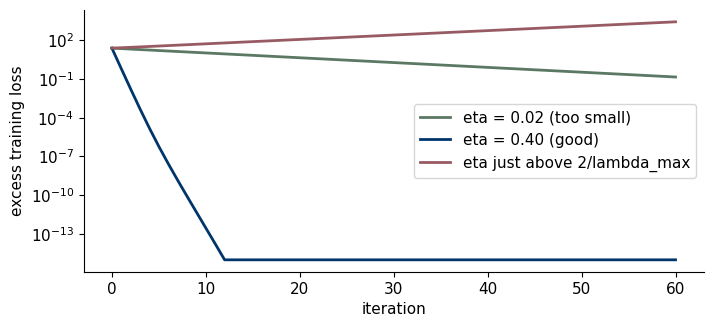

In [13]:
best, *_ = np.linalg.lstsq(Z, yc, rcond=None)
floor = np.mean((yc - Z @ best) ** 2)

fig, ax = plt.subplots()
for lr, color, label in [(0.02, GREEN, 'eta = 0.02 (too small)'),
                         (0.40, BLUE, 'eta = 0.40 (good)'),
                         (1.02 * 2 / lam.max(), RED, 'eta just above 2/lambda_max')]:
    path = gradient_descent(Z, yc, lr, 60)
    excess = ((yc[None] - path @ Z.T) ** 2).mean(axis=1) - floor
    ax.semilogy(np.maximum(excess, 1e-15), color=color, lw=2, label=label)
ax.set(xlabel='iteration', ylabel='excess training loss')
ax.legend()
plt.show()

### Why standardizing mattered

Repeat the fit on the raw scale, where TV varies over hundreds and radio only over tens.

In [14]:
Zraw = np.c_[x - x.mean(), ad['radio'] - ad['radio'].mean()]

for name, M in [('standardized', Z), ('raw scale', Zraw)]:
    lam_m = np.linalg.eigvalsh(2 / len(yc) * M.T @ M)
    print(f'{name:14s} lambda_min = {lam_m.min():9.4f}   lambda_max = {lam_m.max():10.4f}'
          f'   kappa = {lam_m.max()/lam_m.min():8.1f}')

standardized   lambda_min =    1.8855   lambda_max =     2.1045   kappa =      1.1
raw scale      lambda_min =  437.2930   lambda_max = 14669.5485   kappa =     33.5


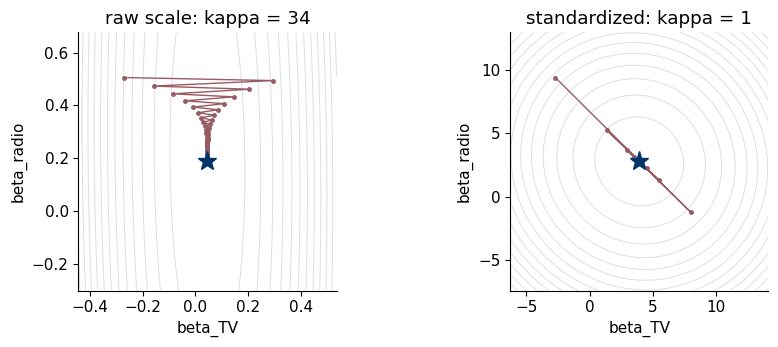

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for ax, (name, M) in zip(axes, [('raw scale', Zraw), ('standardized', Z)]):
    bstar, *_ = np.linalg.lstsq(M, yc, rcond=None)
    lam_m = np.linalg.eigvalsh(2 / len(yc) * M.T @ M)
    span = 2.6 * np.abs(bstar).max()
    g = [np.linspace(bstar[i] - span, bstar[i] + span, 120) for i in (0, 1)]
    G0, G1 = np.meshgrid(*g)
    R = ((yc[:, None, None] - G0[None] * M[:, 0][:, None, None]
          - G1[None] * M[:, 1][:, None, None]) ** 2).mean(axis=0)
    ax.contour(G0, G1, R, levels=16, colors='#D8E0E8', linewidths=0.7)
    path = gradient_descent(M, yc, 1.8 / lam_m.max(), 60,
                            beta0=(bstar[0] - 0.65 * span, bstar[1] + 0.65 * span))
    ax.plot(path[:, 0], path[:, 1], '-o', ms=2.5, lw=1, color=RED)
    ax.plot(*bstar, marker='*', ms=14, color=BLUE)
    ax.set(xlabel='beta_TV', ylabel='beta_radio',
           title=f'{name}: kappa = {lam_m.max()/lam_m.min():.0f}')
    ax.set_aspect('equal')
plt.tight_layout(); plt.show()

The raw-scale problem has an elongated bowl, and gradient descent bounces across the narrow
direction instead of running down it. That ratio $\kappa=\lambda_{\max}/\lambda_{\min}$ is the
**condition number**, and it is the subject of Lecture 04.

## 4. Timing: why we give up the exact formula

The closed form costs $O(np^2)$; one gradient step costs $O(np)$. Measure it.

In [16]:
import time

n_big = 20_000
rows = []
for p_big in [50, 100, 200, 400, 800, 1600]:
    Xb = rng.normal(size=(n_big, p_big))
    yb = rng.normal(size=n_big)

    t0 = time.perf_counter()
    for _ in range(3):
        np.linalg.solve(Xb.T @ Xb, Xb.T @ yb)
    exact = (time.perf_counter() - t0) / 3

    theta = np.zeros(p_big)
    t0 = time.perf_counter()
    for _ in range(50):
        theta -= 1e-5 * (2 / n_big * Xb.T @ (Xb @ theta - yb))
    step = (time.perf_counter() - t0) / 50

    rows.append({'p': p_big, 'exact solve (ms)': exact * 1e3,
                 'one GD step (ms)': step * 1e3, 'GD steps per solve': exact / step})

pd.DataFrame(rows).round(3)

,p,exact solve (ms),one GD step (ms),GD steps per solve
0,50,12.186,14.155,0.861
1,100,19.019,37.441,0.508
2,200,1020.424,85.912,11.877
3,400,2669.884,110.811,24.094
4,800,3131.536,138.442,22.620
5,1600,4607.316,210.172,21.922


Read the last column: at $p=1600$ you can afford dozens of gradient steps for the price of a
single exact solve. And the gap widens with $p$, because one column scales like $p^2$ and the
other like $p$.

## 5. How accurately do we need to optimize?

The slide argued

$$\underbrace{\beta^{(k)}-\beta^\star}_{\text{total}}
=\underbrace{(\beta^{(k)}-\widehat\beta)}_{\text{optimization}}
+\underbrace{(\widehat\beta-\beta^\star)}_{\text{statistical}},$$

and that only the first term responds to running longer. On real data we never see
$\beta^\star$, so we simulate a world where we do.

In [17]:
n_sim, p_sim, sigma = 400, 20, 1.0
idx = np.arange(p_sim)
corr = 0.9 ** np.abs(idx[:, None] - idx[None, :])   # correlated features
Xs = rng.normal(size=(n_sim, p_sim)) @ np.linalg.cholesky(corr).T
beta_star = rng.normal(size=p_sim)
ys = Xs @ beta_star + sigma * rng.normal(size=n_sim)

beta_hat, *_ = np.linalg.lstsq(Xs, ys, rcond=None)
stat_err = np.linalg.norm(beta_hat - beta_star)
print(f'statistical error ||beta_hat - beta_star|| = {stat_err:.4f}')

statistical error ||beta_hat - beta_star|| = 0.8263


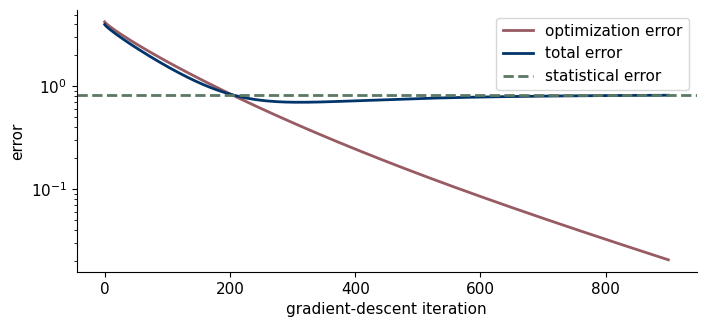

In [18]:
lr = 1.0 / np.linalg.eigvalsh(Xs.T @ Xs / n_sim).max()
path = gradient_descent(Xs, ys, lr / 2, 900)
opt_err = np.linalg.norm(path - beta_hat, axis=1)
tot_err = np.linalg.norm(path - beta_star, axis=1)

fig, ax = plt.subplots()
ax.semilogy(opt_err, color=RED, lw=2, label='optimization error')
ax.semilogy(tot_err, color=BLUE, lw=2, label='total error')
ax.axhline(stat_err, color=GREEN, lw=2, ls='--', label='statistical error')
ax.set(xlabel='gradient-descent iteration', ylabel='error')
ax.legend()
plt.show()

The red curve keeps falling. The blue curve stops the instant it touches the green line and
never improves again. **Optimizing harder buys accuracy in the wrong quantity.**

---

### Where this goes next

Lecture 04 picks up the loose end from part 3: the condition number $\kappa$, why it sets the
*number* of iterations, and how ridge regression improves both the conditioning and the
collinearity we found in part 2.

**Data:** `Advertising`, from *An Introduction to Statistical Learning with Applications in
Python* (James, Witten, Hastie, Tibshirani, Taylor; Springer, 2023), <https://www.statlearning.com/>.

## Part 2 --- every figure in the slides

These cells are the code that produced the figures in the deck, with each file write replaced by an inline plot.

In [19]:
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# The course palette and figure sizes, copied from slides/figures/sds265_style.py
BLUE, BLUE_BRIGHT, RED, GREEN = '#00356B', '#286DC0', '#7A3E47', '#5B7864'
INK, MUTED, RULE, BLUE_PALE = '#202A35', '#66727E', '#D8E0E8', '#F2F6FA'
BLUE_FILL, RED_FILL, GREEN_FILL = '#7B8FA3', '#A3838A', '#8FA394'
CYCLE = [BLUE, RED, GREEN, BLUE_BRIGHT, MUTED]
TEXTWIDTH, TEXTHEIGHT = 5.63, 3.09
FULL, FULL_TALL, FULL_SHORT = (TEXTWIDTH, 2.0), (TEXTWIDTH, 2.35), (TEXTWIDTH, 1.7)
HALF, HALF_TALL = (2.70, 2.05), (2.70, 2.45)

def use_course_style():
    mpl.rcParams.update({'figure.dpi': 130, 'font.size': 9, 'axes.titlecolor': BLUE,
                         'axes.edgecolor': MUTED, 'axes.linewidth': .7,
                         'axes.spines.top': False, 'axes.spines.right': False,
                         'xtick.color': MUTED, 'ytick.color': MUTED,
                         'legend.frameon': False, 'lines.linewidth': 1.8,
                         'axes.prop_cycle': mpl.cycler(color=CYCLE)})

def save(fig, *paths):     # the deck writes files; the notebook shows the plot
    plt.show()
    return Path(paths[0]) if paths else Path('figure.pdf')

use_course_style()
# The figure scripts locate the data through OUT.parents[2]; point OUT at the
# directory the deck uses because figure names are derived from it.
COURSE = Path.cwd().parents[1]
OUT = COURSE / 'slides' / 'figures' / '03-linear-regression'
NOTES = COURSE / 'lectures' / 'figures'

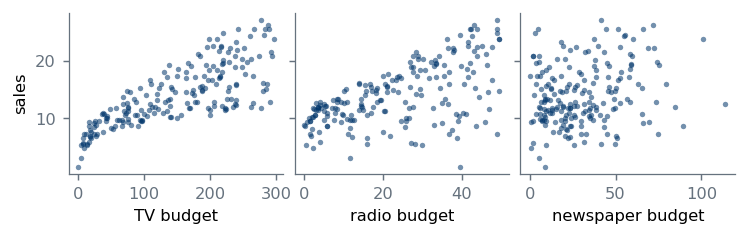

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/03-linear-regression/advertising-panels-raw.pdf')

In [20]:
from __future__ import annotations


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


_COST: dict = {}

#: The Quarto lecture notes render to HTML, so they need SVG copies.
NOTES = OUT.parents[2] / "lectures" / "figures"


def notes_svg(name: str) -> Path:
    """Path of the notes copy of a figure, using the chapter naming scheme."""
    return NOTES / f"ch04-{name}.svg"

ad = pd.read_csv('Advertising.csv', index_col=0)
tv, radio, news, sales = ad.TV.values, ad.radio.values, ad.newspaper.values, ad.sales.values


def ols(X, y):
    """Least squares by QR, returning coefficients, standard errors, residuals."""
    X = np.asarray(X, float)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    n, p = X.shape
    sigma2 = resid @ resid / (n - p)
    cov = sigma2 * np.linalg.inv(X.T @ X)
    return beta, np.sqrt(np.diag(cov)), resid, sigma2


ones = np.ones_like(tv)
beta_tv, se_tv, res_tv, s2_tv = ols(np.c_[ones, tv], sales)
beta_all, se_all, res_all, s2_all = ols(np.c_[ones, tv, radio, news], sales)


# --- 1a. The raw scatter, before any model has been introduced --------------
def fig_panels_raw():
    """The opening look at the data.

    Deliberately has no fitted line: at this point in the lecture neither the
    linear model nor least squares has been introduced, so a line would be
    unexplained. It appears once it has been earned.
    """
    fig, axes = plt.subplots(1, 3, figsize=FULL_SHORT, sharey=True)
    for ax, (x, name) in zip(axes, [(tv, "TV"), (radio, "radio"), (news, "newspaper")]):
        ax.scatter(x, sales, s=9, color=BLUE, alpha=0.55, linewidths=0)
        ax.set_xlabel(f"{name} budget")
    axes[0].set_ylabel("sales")
    fig.tight_layout(pad=0.3)
    return save(fig, OUT / "advertising-panels-raw.pdf", notes_svg("advertising-panels-raw"))

fig_panels_raw()

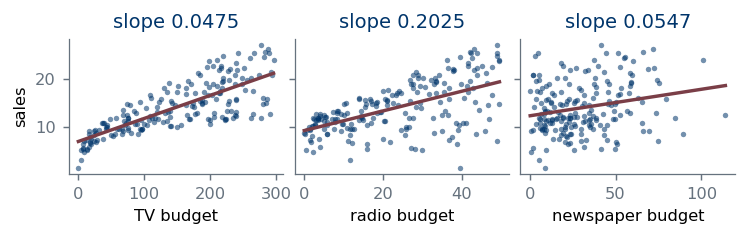

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/03-linear-regression/advertising-panels.pdf')

In [21]:
# --- 1b. The same panels once a line can be justified -----------------------
def fig_panels():
    fig, axes = plt.subplots(1, 3, figsize=FULL_SHORT, sharey=True)
    for ax, (x, name) in zip(axes, [(tv, "TV"), (radio, "radio"), (news, "newspaper")]):
        ax.scatter(x, sales, s=9, color=BLUE, alpha=0.55, linewidths=0)
        b, *_ = ols(np.c_[np.ones_like(x), x], sales)
        grid = np.linspace(x.min(), x.max(), 2)
        ax.plot(grid, b[0] + b[1] * grid, color=RED, lw=1.9)
        ax.set_xlabel(f"{name} budget")
        ax.set_title(f"slope {b[1]:.4f}")
    axes[0].set_ylabel("sales")
    fig.tight_layout(pad=0.3)
    return save(fig, OUT / "advertising-panels.pdf", notes_svg("advertising-panels"))

fig_panels()

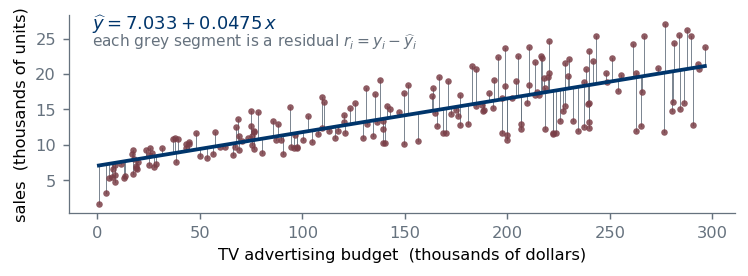

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/03-linear-regression/advertising-tv-fit.pdf')

In [22]:
# --- 2. ISLP Fig. 3.1 recreation: the fit and its vertical residuals --------
def fig_tv_fit():
    fig, ax = plt.subplots(figsize=FULL)
    order = np.argsort(tv)
    fit = beta_tv[0] + beta_tv[1] * tv
    for xi, yi, fi in zip(tv, sales, fit):
        ax.plot([xi, xi], [fi, yi], color=MUTED, lw=0.55, alpha=0.85, zorder=1)
    ax.scatter(tv, sales, s=13, color=RED, alpha=0.85, linewidths=0, zorder=3)
    ax.plot(tv[order], fit[order], color=BLUE, lw=2.1, zorder=4)
    ax.set_xlabel("TV advertising budget  (thousands of dollars)")
    ax.set_ylabel("sales  (thousands of units)")
    ax.annotate(
        rf"$\widehat{{y}} = {beta_tv[0]:.3f} + {beta_tv[1]:.4f}\,x$",
        xy=(0.035, 0.93),
        xycoords="axes fraction",
        color=BLUE,
        fontsize=10,
    )
    ax.annotate(
        r"each grey segment is a residual $r_i = y_i - \widehat{y}_i$",
        xy=(0.035, 0.845),
        xycoords="axes fraction",
        color=MUTED,
        fontsize=8.5,
    )
    fig.tight_layout(pad=0.3)
    return save(fig, OUT / "advertising-tv-fit.pdf", notes_svg("advertising-tv-fit"))

fig_tv_fit()

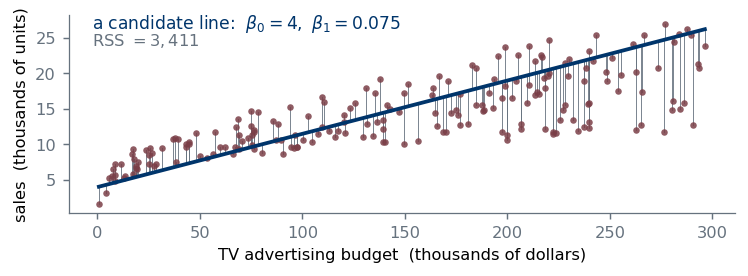

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/03-linear-regression/candidate-line.pdf')

In [23]:
# --- 2b. Residuals measured against a line we have NOT yet optimized -------
def fig_candidate_line():
    """Residuals to an arbitrary candidate line.

    Used where residuals and RSS are defined, which is before least squares has
    been derived. Showing the fitted line there would quote coefficients the
    lecture has not yet computed; a deliberately suboptimal line makes the point
    that RSS is a function of whichever line you pick.
    """
    b0, b1 = 4.0, 0.075          # a plausible but clearly suboptimal guess
    fit = b0 + b1 * tv
    rss = float(((sales - fit) ** 2).sum())

    fig, ax = plt.subplots(figsize=FULL)
    order = np.argsort(tv)
    for xi, yi, fi in zip(tv, sales, fit):
        ax.plot([xi, xi], [fi, yi], color=MUTED, lw=0.55, alpha=0.85, zorder=1)
    ax.scatter(tv, sales, s=13, color=RED, alpha=0.85, linewidths=0, zorder=3)
    ax.plot(tv[order], fit[order], color=BLUE, lw=2.1, zorder=4)
    ax.set_xlabel("TV advertising budget  (thousands of dollars)")
    ax.set_ylabel("sales  (thousands of units)")
    ax.annotate(rf"a candidate line:  $\beta_0={b0:.0f},\ \beta_1={b1:.3f}$",
                xy=(0.035, 0.93), xycoords="axes fraction", color=BLUE, fontsize=9.5)
    ax.annotate(rf"RSS $= {rss:,.0f}$",
                xy=(0.035, 0.845), xycoords="axes fraction", color=MUTED, fontsize=9)
    fig.tight_layout(pad=0.3)
    return save(fig, OUT / "candidate-line.pdf", notes_svg("candidate-line"))

fig_candidate_line()

/var/folders/dw/twkl7xz54f59zmk2mt5tr7t40000gn/T/ipykernel_84580/3947098860.py:40: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(pad=0.25)


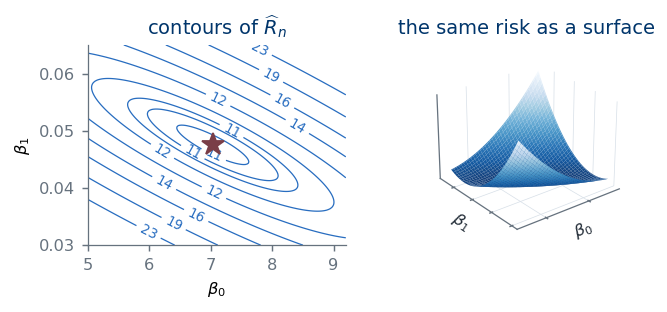

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/03-linear-regression/rss-surface.pdf')

In [24]:
# --- 3. ISLP Fig. 3.2 recreation: the RSS surface over (beta0, beta1) -------
def fig_rss_surface():
    b0 = np.linspace(5.0, 9.2, 150)
    b1 = np.linspace(0.030, 0.065, 150)
    B0, B1 = np.meshgrid(b0, b1)
    resid = sales[:, None, None] - B0[None] - B1[None] * tv[:, None, None]
    RSS = (resid**2).mean(axis=0)          # the empirical risk, not the sum

    fig = plt.figure(figsize=FULL)
    ax1 = fig.add_subplot(1, 2, 1)
    levels = np.array([10.6, 10.8, 11.0, 11.5, 12.5, 14.0, 16.0, 19.0, 23.0])
    cs = ax1.contour(B0, B1, RSS, levels=levels, colors=BLUE_BRIGHT, linewidths=0.7)
    ax1.clabel(cs, inline=True, fontsize=7.5, fmt="%.0f")
    ax1.plot(beta_tv[0], beta_tv[1], marker="*", ms=13, color=RED, zorder=5)
    ax1.set_xlabel(r"$\beta_0$")
    ax1.set_ylabel(r"$\beta_1$")
    ax1.set_title(r"contours of $\widehat{R}_n$")

    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    ax2.plot_surface(
        B0, B1, RSS, cmap="Blues_r", linewidth=0, antialiased=True,
        alpha=0.95, rstride=4, cstride=4,
    )
    # Quiet the default 3D furniture so the bowl itself is the only message.
    for pane_axis in (ax2.xaxis, ax2.yaxis, ax2.zaxis):
        pane_axis.pane.set_alpha(0.0)
        pane_axis.pane.set_edgecolor("none")
        pane_axis._axinfo["grid"].update(color=RULE, linewidth=0.4)
    # The contour panel carries the numbers; the surface only has to show the
    # shape, so its tick labels are removed rather than shrunk to illegibility.
    ax2.set_xlabel(r"$\beta_0$", labelpad=-12, color=INK)
    ax2.set_ylabel(r"$\beta_1$", labelpad=-12, color=INK)
    ax2.set_xticklabels([])
    ax2.set_yticklabels([])
    ax2.set_zticks([])
    ax2.tick_params(length=0)
    ax2.view_init(elev=26, azim=-128)
    ax2.set_box_aspect((1, 1, 0.72))
    ax2.set_title("the same risk as a surface")
    fig.tight_layout(pad=0.25)
    return save(fig, OUT / "rss-surface.pdf", notes_svg("rss-surface"))

fig_rss_surface()

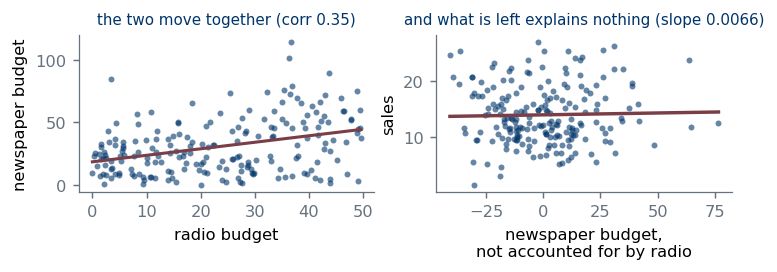

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/03-linear-regression/newspaper-confounding.pdf')

In [25]:
# --- 4. Why the newspaper coefficient dies in the multiple fit --------------
def fig_confounding():
    """A purely predictive account of the vanishing newspaper effect.

    Left: newspaper and radio budgets move together. Right: strip out the part
    of newspaper that radio already predicts, and what is left has essentially
    no relationship with sales. No inference, no p-values.
    """
    fig, axes = plt.subplots(1, 2, figsize=FULL)

    ax = axes[0]
    ax.scatter(radio, news, s=11, color=BLUE, alpha=0.6, linewidths=0)
    b, *_ = ols(np.c_[np.ones_like(radio), radio], news)
    grid = np.linspace(radio.min(), radio.max(), 2)
    ax.plot(grid, b[0] + b[1] * grid, color=RED, lw=1.7)
    ax.set_xlabel("radio budget")
    ax.set_ylabel("newspaper budget")
    ax.set_title(f"the two move together (corr {np.corrcoef(radio, news)[0,1]:.2f})",
                 fontsize=8.4)

    # The part of newspaper that radio cannot predict.
    news_res = news - (b[0] + b[1] * radio)
    ax = axes[1]
    ax.scatter(news_res, sales, s=11, color=BLUE, alpha=0.6, linewidths=0)
    c, *_ = ols(np.c_[np.ones_like(news_res), news_res], sales)
    g2 = np.linspace(news_res.min(), news_res.max(), 2)
    ax.plot(g2, c[0] + c[1] * g2, color=RED, lw=1.9)
    ax.set_xlabel("newspaper budget,\nnot accounted for by radio")
    ax.set_ylabel("sales")
    ax.set_title(f"and what is left explains nothing (slope {c[1]:.4f})", fontsize=8.4)
    fig.tight_layout(pad=0.4)
    return save(fig, OUT / "newspaper-confounding.pdf", notes_svg("newspaper-confounding"))

fig_confounding()

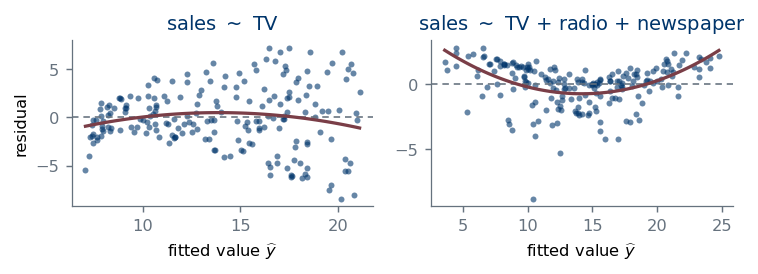

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/03-linear-regression/residual-diagnostics.pdf')

In [26]:
# --- 5. Residual diagnostics: the TV-only fit is visibly wrong --------------
def fig_diagnostics():
    fig, axes = plt.subplots(1, 2, figsize=FULL)
    fit_tv = beta_tv[0] + beta_tv[1] * tv
    fit_all = beta_all[0] + beta_all[1] * tv + beta_all[2] * radio + beta_all[3] * news

    panels = [
        (fit_tv, res_tv, r"sales $\sim$ TV"),
        (fit_all, res_all, r"sales $\sim$ TV + radio + newspaper"),
    ]
    for ax, (f, r, title) in zip(axes, panels):
        ax.scatter(f, r, s=11, color=BLUE, alpha=0.6, linewidths=0)
        ax.axhline(0.0, color=MUTED, lw=0.9, ls=(0, (4, 3)))
        # A quadratic fit to the residuals is enough to expose the curvature
        # students should see; no extra dependency needed.
        q = np.polyfit(f, r, 2)
        grid = np.linspace(f.min(), f.max(), 120)
        ax.plot(grid, np.polyval(q, grid), color=RED, lw=1.8)
        ax.set_xlabel(r"fitted value $\widehat{y}$")
        ax.set_title(title)
    axes[0].set_ylabel("residual")
    fig.tight_layout(pad=0.35)
    return save(fig, OUT / "residual-diagnostics.pdf", notes_svg("residual-diagnostics"))

fig_diagnostics()

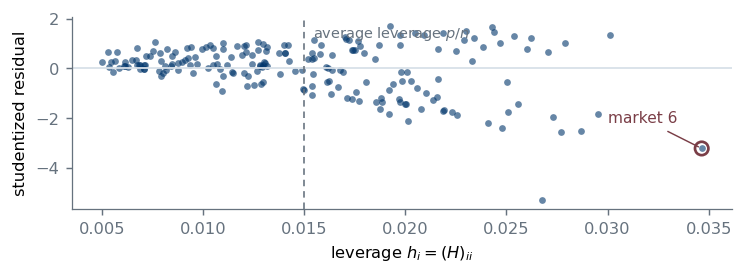

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/03-linear-regression/leverage-influence.pdf')

In [27]:
# --- 6. Leverage and influence ---------------------------------------------
def fig_leverage():
    X = np.c_[ones, tv, radio]
    _, _, res, s2 = ols(X, sales)
    H = X @ np.linalg.solve(X.T @ X, X.T)
    h = np.diag(H)
    stud = res / np.sqrt(s2 * (1.0 - h))
    n, p = X.shape

    fig, ax = plt.subplots(figsize=FULL)
    ax.scatter(h, stud, s=14, color=BLUE, alpha=0.6, linewidths=0)
    ax.axhline(0.0, color=RULE, lw=1.0)
    ax.axvline(p / n, color=MUTED, lw=0.9, ls=(0, (4, 3)))
    top = ax.get_ylim()[1]
    ax.annotate(
        r"average leverage $p/n$",
        xy=(p / n, top),
        xytext=(5, -11),
        textcoords="offset points",
        color=MUTED,
        fontsize=8,
    )
    worst = int(np.argmax(h))
    ax.scatter([h[worst]], [stud[worst]], s=55, facecolor="none", edgecolor=RED, lw=1.5)
    ax.annotate(
        f"market {ad.index[worst]}",
        xy=(h[worst], stud[worst]),
        xytext=(-52, 14),
        textcoords="offset points",
        color=RED,
        fontsize=8.5,
        arrowprops=dict(arrowstyle="-", color=RED, lw=0.8),
    )
    ax.set_xlabel(r"leverage $h_i = (H)_{ii}$")
    ax.set_ylabel("studentized residual")
    fig.tight_layout(pad=0.3)
    return save(fig, OUT / "leverage-influence.pdf", notes_svg("leverage-influence"))

fig_leverage()

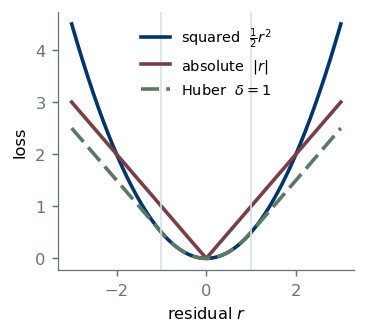

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/03-linear-regression/loss-shapes.pdf')

In [28]:
# --- 7. Squared versus absolute loss ---------------------------------------
def fig_loss_shapes():
    """Squared, absolute, and Huber loss.

    Huber is quadratic near zero, so it keeps a unique smooth minimum, and
    linear in the tails, so a single wild observation cannot dominate.
    """
    r = np.linspace(-3, 3, 600)
    delta = 1.0
    huber = np.where(np.abs(r) <= delta, 0.5 * r**2, delta * (np.abs(r) - 0.5 * delta))
    fig, ax = plt.subplots(figsize=HALF_TALL)
    ax.plot(r, 0.5 * r**2, color=BLUE, lw=2.0, label=r"squared  $\frac{1}{2}r^2$")
    ax.plot(r, np.abs(r), color=RED, lw=2.0, label=r"absolute  $|r|$")
    ax.plot(r, huber, color=GREEN, lw=2.0, ls=(0, (5, 2)),
            label=rf"Huber  $\delta={delta:.0f}$")
    ax.axvline(-delta, color=RULE, lw=0.9)
    ax.axvline(delta, color=RULE, lw=0.9)
    ax.set_xlabel(r"residual $r$")
    ax.set_ylabel("loss")
    ax.legend(loc="upper center", fontsize=8.0)
    fig.tight_layout(pad=0.3)
    return save(fig, OUT / "loss-shapes.pdf", notes_svg("loss-shapes"))

fig_loss_shapes()

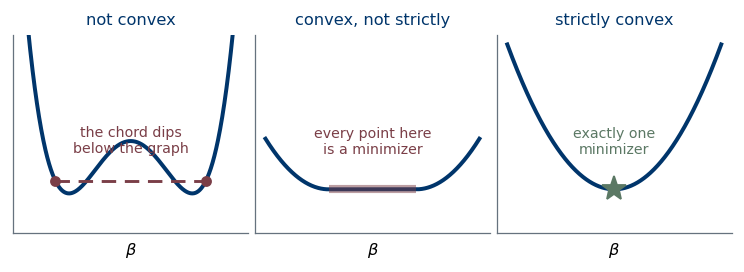

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/03-linear-regression/convexity.pdf')

In [29]:
# --- 8. Gradient descent on the Advertising least-squares problem ----------


# --- 9. The error decomposition: optimization versus statistical error ------


def report():
    """Print every number quoted on the slides so it can be checked."""
    tss = float(((sales - sales.mean()) ** 2).sum())
    print(f"simple   sales ~ TV : b0={beta_tv[0]:.4f} (se {se_tv[0]:.4f}), "
          f"b1={beta_tv[1]:.4f} (se {se_tv[1]:.4f})")
    print(f"           t = {beta_tv[0]/se_tv[0]:.2f}, {beta_tv[1]/se_tv[1]:.2f}; "
          f"RSE={np.sqrt(s2_tv):.3f}; R^2={1 - res_tv @ res_tv / tss:.4f}; "
          f"RSS={res_tv @ res_tv:.1f}; TSS={tss:.1f}")
    print("multiple sales ~ TV + radio + newspaper:")
    for lab, b, s in zip(["intercept", "TV", "radio", "newspaper"], beta_all, se_all):
        print(f"           {lab:10s} {b:9.4f}  se {s:.4f}  t {b / s:7.2f}")
    print(f"           RSE={np.sqrt(s2_all):.3f}, R^2={1 - res_all @ res_all / tss:.4f}")
    print(f"           corr(radio, newspaper) = {np.corrcoef(radio, news)[0, 1]:.4f}")
    if _COST:
        print(f"timing  n={_COST['n']:,}")
        for p_, e, g in zip(_COST["ps"], _COST["exact"], _COST["grad"]):
            print(f"           p={p_:5d}  exact {e*1000:9.2f} ms   one GD step {g*1000:7.3f} ms"
                  f"   ratio {e/g:8.1f}")
    xbar, ybar = tv.mean(), sales.mean()
    sxy = float(((tv - xbar) * (sales - ybar)).sum())
    sxx = float(((tv - xbar) ** 2).sum())
    print(f"worked   xbar={xbar:.3f} ybar={ybar:.3f} Sxy={sxy:.1f} Sxx={sxx:.1f} "
          f"-> b1={sxy / sxx:.6f}, b0={ybar - sxy / sxx * xbar:.4f}")




# --- 10. Convexity: the tangent-line property and what uniqueness needs -----
def fig_convexity():
    """Nonconvex, convex-but-not-strictly, and strictly convex, side by side."""
    fig, axes = plt.subplots(1, 3, figsize=FULL)
    t = np.linspace(-2.2, 2.2, 600)

    # (a) not convex: a chord can pass below the graph
    nc = 0.42 * t**4 - 1.35 * t**2 + 1.4
    ax = axes[0]
    ax.plot(t, nc, color=BLUE, lw=2.2)
    a, b = -1.55, 1.55
    fa = 0.42 * a**4 - 1.35 * a**2 + 1.4
    fb = 0.42 * b**4 - 1.35 * b**2 + 1.4
    ax.plot([a, b], [fa, fb], color=RED, lw=1.6, ls=(0, (5, 3)))
    ax.plot([a, b], [fa, fb], "o", ms=5, color=RED)
    ax.annotate("the chord dips\nbelow the graph", xy=(0, 0.5 * (fa + fb)),
                xytext=(0, 16), textcoords="offset points", ha="center",
                color=RED, fontsize=7.8)
    ax.set_title("not convex", fontsize=9)

    # (b) convex but not strictly: a flat stretch of minimizers
    g = np.where(np.abs(t) <= 0.9, 0.4, 0.62 * (np.abs(t) - 0.9) ** 2 + 0.4)
    ax = axes[1]
    ax.plot(t, g, color=BLUE, lw=2.2)
    ax.plot([-0.9, 0.9], [0.4, 0.4], color=RED, lw=4.5, alpha=0.5,
            solid_capstyle="butt")
    ax.annotate("every point here\nis a minimizer", xy=(0, 0.4), xytext=(0, 20),
                textcoords="offset points", ha="center", color=RED, fontsize=7.8)
    ax.set_title("convex, not strictly", fontsize=9)

    # (c) strictly convex: exactly one minimizer
    sc = 0.62 * t**2 + 0.4
    ax = axes[2]
    ax.plot(t, sc, color=BLUE, lw=2.2)
    ax.plot([0], [0.4], "*", ms=14, color=GREEN)
    ax.annotate("exactly one\nminimizer", xy=(0, 0.4), xytext=(0, 20),
                textcoords="offset points", ha="center", color=GREEN, fontsize=7.8)
    ax.set_title("strictly convex", fontsize=9)

    for ax in axes:
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_xlabel(r"$\beta$")
        ax.set_ylim(-0.5, 3.6)
    fig.tight_layout(pad=0.4)
    return save(fig, OUT / "convexity.pdf", notes_svg("convexity"))

fig_convexity()

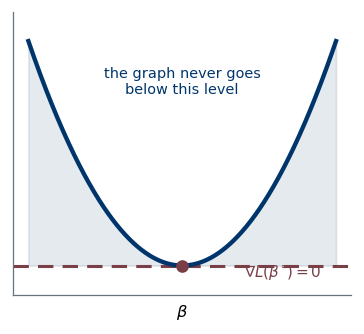

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/03-linear-regression/stationary-global.pdf')

In [30]:
# --- 10d. A stationary point of a convex function is a global minimum -------
def fig_stationary_global():
    """At a flat point the tangent is horizontal, and the graph stays above it."""
    t = np.linspace(-2.4, 2.4, 500)
    f = 0.6 * t**2 + 0.5
    fig, ax = plt.subplots(figsize=HALF_TALL)
    ax.plot(t, f, color=BLUE, lw=2.4, zorder=3)
    ax.axhline(0.5, color=RED, lw=1.7, ls=(0, (5, 3)), zorder=2)
    ax.fill_between(t, 0.5, f, color=BLUE, alpha=0.10, zorder=1)
    ax.plot([0], [0.5], "o", ms=6, color=RED, zorder=4)
    ax.annotate(r"$\nabla L(\beta^{\circ})=0$", xy=(0, 0.5), xytext=(34, -6),
                textcoords="offset points", ha="left", color=RED, fontsize=8.4)
    ax.annotate("the graph never goes\nbelow this level", xy=(0, 3.15),
                xytext=(0, 0), textcoords="offset points", ha="center",
                color=BLUE, fontsize=8.0)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel(r"$\beta$")
    ax.set_ylim(0.05, 4.4)
    fig.tight_layout(pad=0.3)
    return save(fig, OUT / "stationary-global.pdf", notes_svg("stationary-global"))

fig_stationary_global()

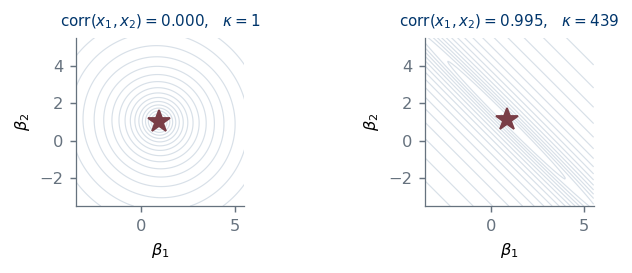

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/03-linear-regression/collinearity-contours.pdf')

In [31]:
# --- 11. Collinearity: the RSS valley and unstable coefficients -------------
def _collinear_design(rho, n=200, seed=0):
    rng = np.random.default_rng(seed)
    z = rng.normal(size=n)
    x1 = z
    x2 = rho * z + np.sqrt(max(1e-12, 1 - rho**2)) * rng.normal(size=n)
    X = np.column_stack([x1, x2])
    X = (X - X.mean(0)) / X.std(0)
    return X


def fig_collinearity_contours():
    """RSS contours for two nearly identical features: a long flat valley."""
    beta_true = np.array([1.0, 1.0])
    fig, axes = plt.subplots(1, 2, figsize=FULL)
    for ax, rho in zip(axes, [0.0, 0.995]):
        X = _collinear_design(rho, seed=3)
        rng = np.random.default_rng(11)
        y = X @ beta_true + 0.5 * rng.normal(size=len(X))
        best, *_ = np.linalg.lstsq(X, y, rcond=None)
        g = np.linspace(-3.5, 5.5, 200)
        G0, G1 = np.meshgrid(g, g)
        R = ((y[:, None, None] - G0[None] * X[:, 0][:, None, None]
              - G1[None] * X[:, 1][:, None, None]) ** 2).mean(axis=0)
        ax.contour(G0, G1, R, levels=np.geomspace(R.min() + 1e-3, R.max(), 18),
                   colors=RULE, linewidths=0.65)
        ax.plot(*best, marker="*", ms=13, color=RED, zorder=5)
        lam = np.linalg.eigvalsh(X.T @ X / len(X))
        ax.set_aspect("equal")
        ax.set_xlabel(r"$\beta_1$")
        ax.set_ylabel(r"$\beta_2$")
        ax.set_title(rf"$\Cor(x_1,x_2)={rho:.3f}$,   $\kappa={lam.max()/lam.min():.0f}$"
                     .replace(r"\Cor", r"\mathrm{corr}"), fontsize=8.4)
    fig.tight_layout(pad=0.4)
    return save(fig, OUT / "collinearity-contours.pdf", notes_svg("collinearity-contours"))

fig_collinearity_contours()

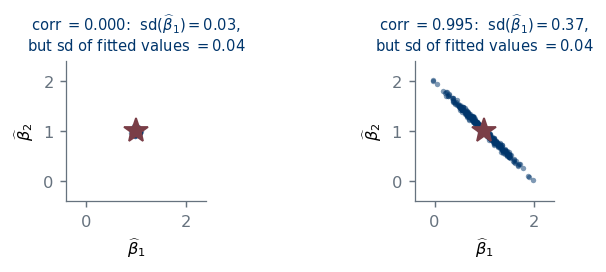

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/03-linear-regression/collinearity-simulation.pdf')

In [32]:
def fig_collinearity_simulation():
    """Refit on fresh noise 200 times; watch the coefficients scatter."""
    beta_true = np.array([1.0, 1.0])
    fig, axes = plt.subplots(1, 2, figsize=FULL)
    for ax, rho in zip(axes, [0.0, 0.995]):
        X = _collinear_design(rho, seed=3)
        rng = np.random.default_rng(7)
        ests, preds = [], []
        for _ in range(300):
            y = X @ beta_true + 0.5 * rng.normal(size=len(X))
            b, *_ = np.linalg.lstsq(X, y, rcond=None)
            ests.append(b)
            preds.append(X @ b)
        ests = np.array(ests)
        spread_pred = np.std(np.array(preds), axis=0).mean()
        ax.scatter(ests[:, 0], ests[:, 1], s=9, color=BLUE, alpha=0.5, linewidths=0)
        ax.plot(*beta_true, marker="*", ms=14, color=RED, zorder=5)
        ax.set_xlim(beta_true[0] - 1.4, beta_true[0] + 1.4)
        ax.set_ylim(beta_true[1] - 1.4, beta_true[1] + 1.4)
        ax.set_aspect("equal")
        ax.set_xlabel(r"$\widehat\beta_1$")
        ax.set_ylabel(r"$\widehat\beta_2$")
        ax.set_title(rf"corr $={rho:.3f}$:  sd$(\widehat\beta_1)={ests[:,0].std():.2f}$,"
                     "\n" rf"but sd of fitted values $={spread_pred:.2f}$", fontsize=8.2)
    fig.tight_layout(pad=0.4)
    return save(fig, OUT / "collinearity-simulation.pdf",
                notes_svg("collinearity-simulation"))

fig_collinearity_simulation()

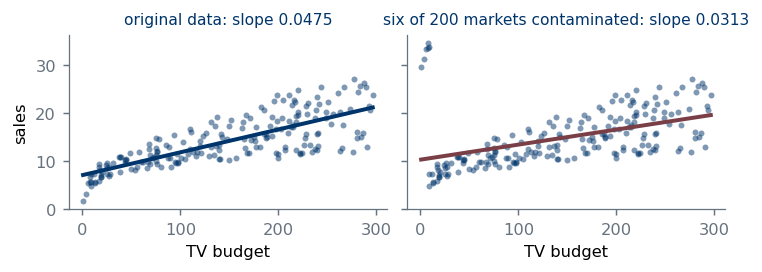

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/03-linear-regression/heavy-tails.pdf')

In [33]:
# --- 12. Heavy-tailed noise breaks least squares ----------------------------
def fig_heavy_tails():
    """Contaminating a handful of markets is enough to move the fit.

    Only the least-squares line is shown: the remedy (Huber, absolute loss) is
    left to the homework, so the slide states the failure without the fix.
    """
    y = sales.copy()
    idx = np.argsort(tv)[:12]
    y_bad = y.copy()
    y_bad[idx[:6]] += 28.0

    X = np.c_[ones, tv]
    grid = np.linspace(tv.min(), tv.max(), 2)
    fig, axes = plt.subplots(1, 2, figsize=FULL, sharey=True)
    for ax, (yv, title, colour) in zip(
        axes,
        [(y, "original data", BLUE), (y_bad, "six of 200 markets contaminated", RED)],
    ):
        b_ols, *_ = np.linalg.lstsq(X, yv, rcond=None)
        ax.scatter(tv, yv, s=11, color=BLUE, alpha=0.5, linewidths=0)
        ax.plot(grid, b_ols[0] + b_ols[1] * grid, color=colour, lw=2.2)
        ax.set_xlabel("TV budget")
        ax.set_title(f"{title}: slope {b_ols[1]:.4f}", fontsize=8.6)
    axes[0].set_ylabel("sales")
    fig.tight_layout(pad=0.4)
    return save(fig, OUT / "heavy-tails.pdf", notes_svg("heavy-tails"))

fig_heavy_tails()

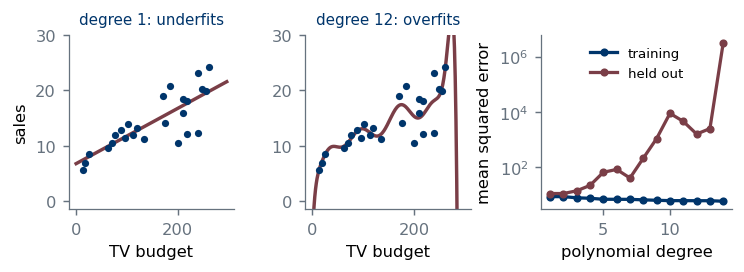

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/03-linear-regression/overfit-underfit.pdf')

In [34]:
# --- 13. Underfitting and overfitting with polynomial features -------------
def fig_overfit_underfit():
    """Polynomial fits of sales on TV, on a small training subset."""
    rng = np.random.default_rng(1)
    perm = rng.permutation(len(tv))
    tr, te = perm[:25], perm[25:]
    xg = np.linspace(tv.min(), tv.max(), 400)

    fig = plt.figure(figsize=FULL)
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.15])
    for k, deg in enumerate([1, 12]):
        ax = fig.add_subplot(gs[0, k])
        c = np.polyfit(tv[tr], sales[tr], deg)
        ax.scatter(tv[tr], sales[tr], s=16, color=BLUE, zorder=3, linewidths=0)
        ax.plot(xg, np.polyval(c, xg), color=RED, lw=1.9)
        ax.set_ylim(sales.min() - 3, sales.max() + 3)
        ax.set_xlabel("TV budget")
        ax.set_title(f"degree {deg}: {'underfits' if deg == 1 else 'overfits'}",
                     fontsize=8.4)
        if k == 0:
            ax.set_ylabel("sales")

    ax = fig.add_subplot(gs[0, 2])
    degs = np.arange(1, 15)
    tr_err, te_err = [], []
    for d in degs:
        c = np.polyfit(tv[tr], sales[tr], d)
        tr_err.append(np.mean((sales[tr] - np.polyval(c, tv[tr])) ** 2))
        te_err.append(np.mean((sales[te] - np.polyval(c, tv[te])) ** 2))
    ax.semilogy(degs, tr_err, "-o", ms=3.5, color=BLUE, label="training")
    ax.semilogy(degs, te_err, "-o", ms=3.5, color=RED, label="held out")
    ax.set_xlabel("polynomial degree")
    ax.set_ylabel("mean squared error")
    ax.legend(loc="upper center", fontsize=7.4)
    fig.tight_layout(pad=0.4)
    return save(fig, OUT / "overfit-underfit.pdf", notes_svg("overfit-underfit"))

fig_overfit_underfit()

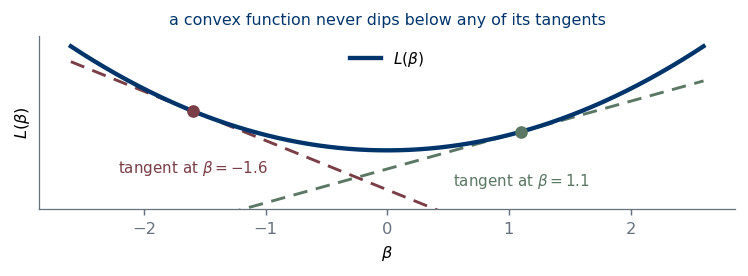

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/03-linear-regression/convexity-tangent.pdf')

In [35]:
# --- 10b. The tangent-line characterisation, in one variable ---------------
def fig_convexity_tangent():
    """A convex curve with two tangent lines, both lying below it.

    Lecture 03 states the first-order condition rather than deriving it, so the
    picture has to carry the intuition.
    """
    t = np.linspace(-2.6, 2.6, 500)
    f = lambda z: 0.55 * z**2 + 0.5
    g = lambda z: 1.10 * z

    fig, ax = plt.subplots(figsize=FULL)
    ax.plot(t, f(t), color=BLUE, lw=2.4, zorder=3, label=r"$L(\beta)$")
    for a, col in [(-1.6, RED), (1.1, GREEN)]:
        ax.plot(t, f(a) + g(a) * (t - a), color=col, lw=1.6, ls=(0, (5, 3)), zorder=2)
        ax.plot([a], [f(a)], "o", ms=6, color=col, zorder=4)
        ax.annotate(rf"tangent at $\beta={a:g}$", xy=(a, f(a)),
                    xytext=(0, -34 if a < 0 else -30), textcoords="offset points",
                    ha="center", color=col, fontsize=8.4)
    ax.set_ylim(-1.6, 4.6)
    ax.set_xlabel(r"$\beta$")
    ax.set_ylabel(r"$L(\beta)$")
    ax.set_yticks([])
    ax.legend(loc="upper center", fontsize=8.5)
    ax.set_title("a convex function never dips below any of its tangents", fontsize=8.8)
    fig.tight_layout(pad=0.3)
    return save(fig, OUT / "convexity-tangent.pdf", notes_svg("convexity-tangent"))

fig_convexity_tangent()

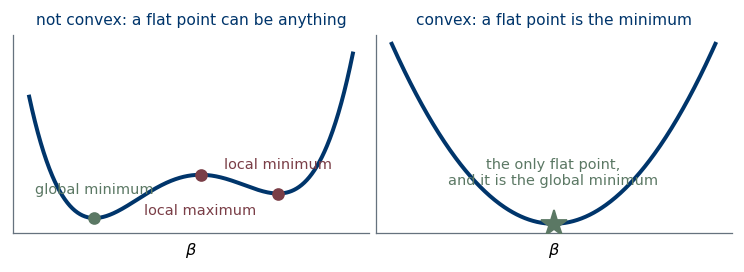

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/03-linear-regression/stationary-points.pdf')

In [36]:
# --- 10c. What a stationary point can be, when the function is not convex --
def fig_stationary_points():
    """Left: a nonconvex objective, with every kind of stationary point.

    Right: a convex one, where the only stationary point is the global minimum.
    This is the picture behind "why did we trust the stationary point?".
    """
    fig, axes = plt.subplots(1, 2, figsize=FULL)

    # A quartic with two minima and one maximum, so every label is honest.
    t = np.linspace(-2.15, 2.15, 900)
    f = t**4 - 3.0 * t**2 + 0.75 * t
    ax = axes[0]
    ax.plot(t, f, color=BLUE, lw=2.2, zorder=3)

    # Exact stationary points: f' = 4t^3 - 6t + 0.75.
    roots = np.sort(np.roots([4.0, 0.0, -6.0, 0.75]).real)
    fr = roots**4 - 3.0 * roots**2 + 0.75 * roots
    curv = 12.0 * roots**2 - 6.0
    gmin = int(np.argmin(np.where(curv > 0, fr, np.inf)))
    for k, (tk, fk, ck) in enumerate(zip(roots, fr, curv)):
        if ck > 0:
            label = "global minimum" if k == gmin else "local minimum"
            colour, dy = (GREEN, 14) if k == gmin else (RED, 14)
        else:
            label, colour, dy = "local maximum", RED, -22
        ax.plot(tk, fk, "o", ms=6, color=colour, zorder=4)
        ax.annotate(label, xy=(tk, fk), xytext=(0, dy), textcoords="offset points",
                    ha="center", color=colour, fontsize=8)
    ax.set_ylim(fr.min() - 1.1, f.max() + 1.4)
    ax.set_title("not convex: a flat point can be anything", fontsize=8.6)

    ax = axes[1]
    tc = np.linspace(-2.4, 2.4, 400)
    fc = 0.7 * tc**2 + 0.4
    ax.plot(tc, fc, color=BLUE, lw=2.2, zorder=3)
    ax.plot([0], [0.4], "*", ms=15, color=GREEN, zorder=4)
    ax.annotate("the only flat point,\nand it is the global minimum",
                xy=(0, 0.4), xytext=(0, 22), textcoords="offset points",
                ha="center", color=GREEN, fontsize=8)
    ax.set_title("convex: a flat point is the minimum", fontsize=8.6)

    for ax in axes:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel(r"$\beta$")
    fig.tight_layout(pad=0.4)
    return save(fig, OUT / "stationary-points.pdf", notes_svg("stationary-points"))

fig_stationary_points()

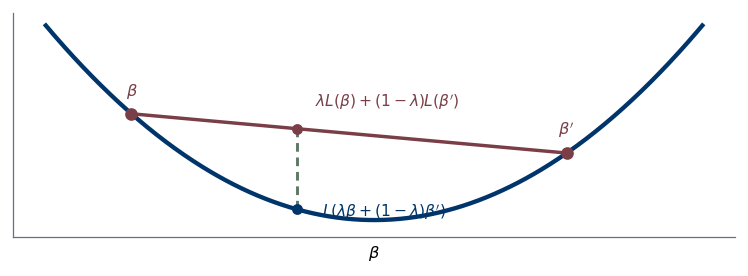

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/03-linear-regression/convexity-chord.pdf')

In [37]:
# --- 10e. The chord definition of convexity, in one variable ---------------
def fig_convexity_chord():
    """A chord between two points of a convex curve stays above the curve."""
    t = np.linspace(-2.3, 2.3, 500)
    f = lambda z: 0.55 * z**2 + 0.5
    a, b = -1.7, 1.35
    lam = 0.62
    mid = lam * a + (1 - lam) * b

    fig, ax = plt.subplots(figsize=FULL)
    ax.plot(t, f(t), color=BLUE, lw=2.4, zorder=3)
    ax.plot([a, b], [f(a), f(b)], color=RED, lw=1.9, zorder=2)
    ax.plot([a, b], [f(a), f(b)], "o", ms=6, color=RED, zorder=4)
    chord_at_mid = lam * f(a) + (1 - lam) * f(b)
    ax.plot([mid, mid], [f(mid), chord_at_mid], color=GREEN, lw=1.6,
            ls=(0, (3, 2)), zorder=4)
    ax.plot([mid], [chord_at_mid], "o", ms=5, color=RED, zorder=5)
    ax.plot([mid], [f(mid)], "o", ms=5, color=BLUE, zorder=5)
    ax.annotate(r"$\lambda L(\beta)+(1-\lambda)L(\beta')$",
                xy=(mid, chord_at_mid), xytext=(10, 12), textcoords="offset points",
                color=RED, fontsize=8.6)
    ax.annotate(r"$L(\lambda\beta+(1-\lambda)\beta')$",
                xy=(mid, f(mid)), xytext=(14, -4), textcoords="offset points",
                color=BLUE, fontsize=8.6)
    for x, lab in [(a, r"$\beta$"), (b, r"$\beta'$")]:
        ax.annotate(lab, xy=(x, f(x)), xytext=(0, 10), textcoords="offset points",
                    ha="center", color=RED, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel(r"$\beta$")
    ax.set_ylim(0.25, 3.6)
    fig.tight_layout(pad=0.3)
    return save(fig, OUT / "convexity-chord.pdf", notes_svg("convexity-chord"))

fig_convexity_chord()